# Importing packages

In [50]:
import numpy as np, pandas as pd, seaborn as sb, matplotlib.pyplot as mlp

# Data directories

In [51]:
customer_dataset = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\cleaned_customers_dataset.csv"
geolocation_data = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\cleaned_geolocation_data.csv"
order_items_data = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\cleaned_order_items_data.csv"
order_payments_data = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\cleaned_order_payments_data.csv"
order_reviews_data = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\cleaned_order_reviews_data.csv"
orders_data = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\cleaned_orders_data.csv"
products_data = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\cleaned_products_data.csv"
sellers_data = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\cleaned_sellers_data.csv"

### Which states have the highest number of customers?

In [52]:
customers = pd.read_csv(customer_dataset)

In [53]:
customers_by_state = customers.groupby('customer_state')['customer_unique_id'].count()

In [54]:
customers_by_state = pd.DataFrame(customers_by_state)

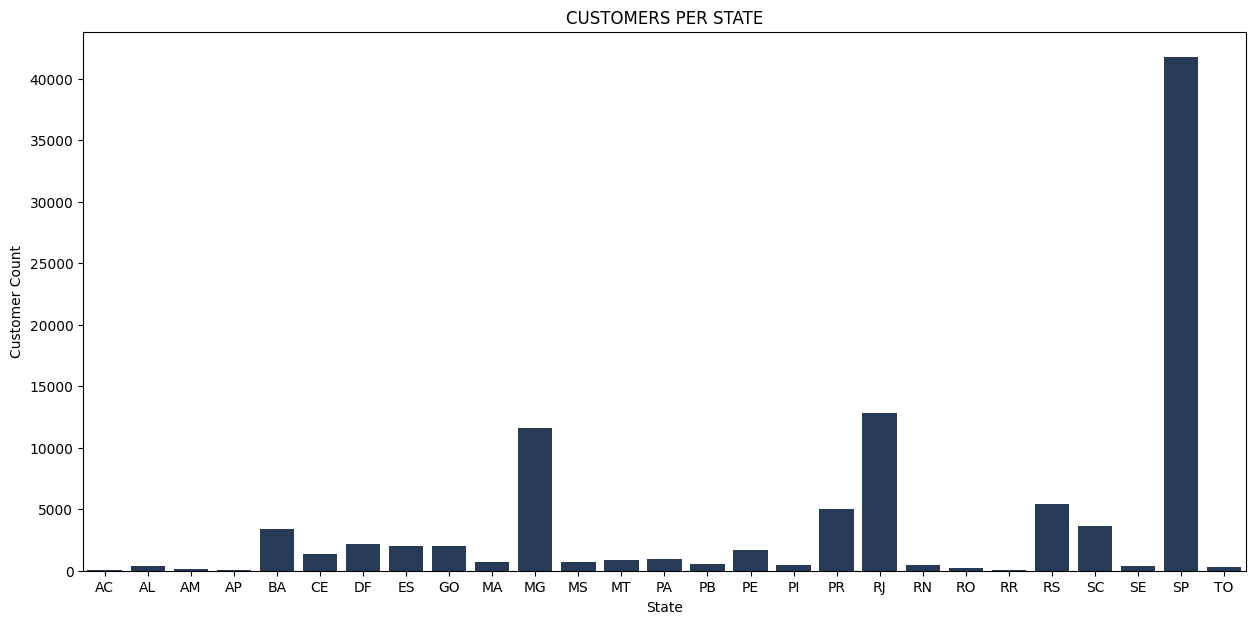

In [55]:
mlp.figure(figsize=(15,7))
mlp.xlabel('State')
mlp.ylabel('Customer Count')
mlp.title('CUSTOMERS PER STATE')
plot = sb.barplot(data=customers_by_state,x='customer_state',y='customer_unique_id')

### Which product categories are ordered the most?

In [56]:
order_items = pd.read_csv(order_items_data)[['order_id','product_id']]

In [57]:
prod_data = pd.read_csv(products_data)[['product_id','product_category_name']]

In [58]:
prod_data = prod_data.set_index('product_id')['product_category_name'].to_dict()

In [59]:
order_items['product_Category'] = order_items['product_id'].map(prod_data)

In [60]:
order_items=order_items[['order_id','product_Category']]

In [61]:
order_items

,order_id,product_Category
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools
...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,housewares
112646,fffcd46ef2263f404302a634eb57f7eb,computers_accessories
112647,fffce4705a9662cd70adb13d4a31832d,sports_leisure
112648,fffe18544ffabc95dfada21779c9644f,computers_accessories


In [62]:
order_items_da = order_items.groupby('product_Category')['order_id'].nunique().to_frame()

In [63]:
order_items_da = order_items_da.sort_values(by='order_id',ascending=False)

<Axes: title={'center': 'Product category demand'}, xlabel='Category', ylabel='Orders count'>

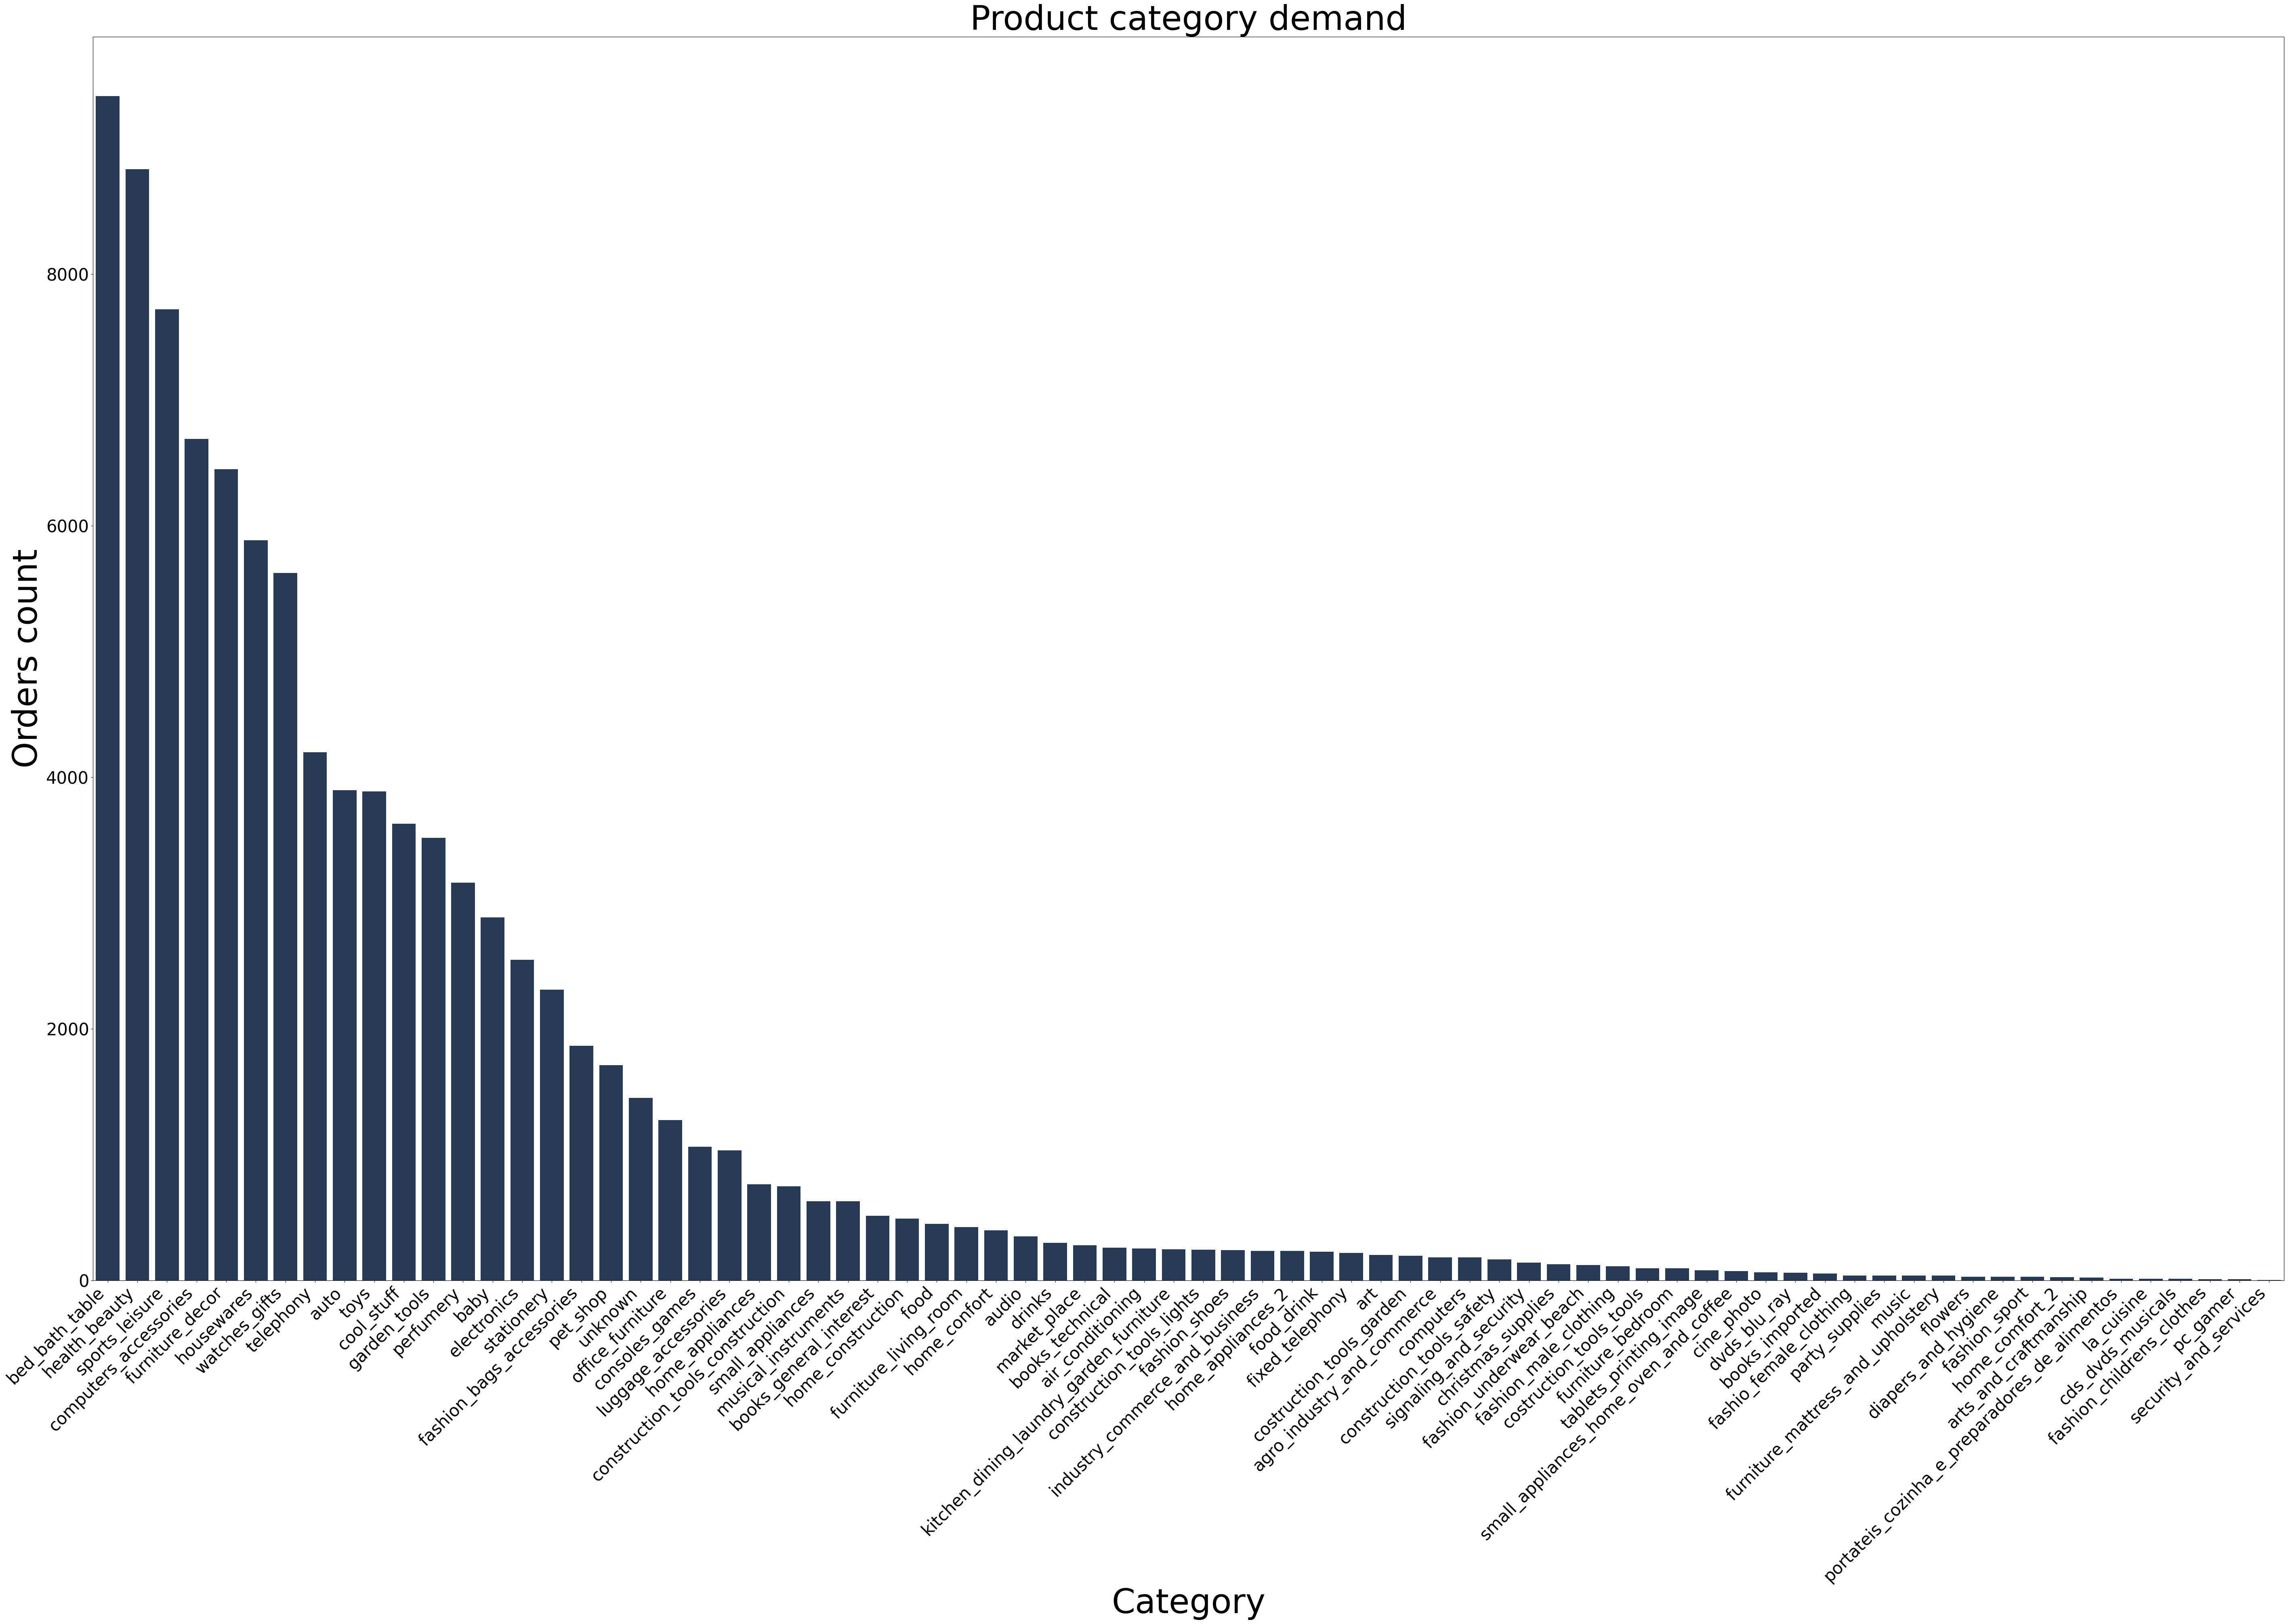

In [64]:
mlp.figure(figsize=(70,40))
mlp.title('Product category demand',fontsize=60)
mlp.xlabel('Category',fontsize=60)
mlp.ylabel('Orders count',fontsize=60)
mlp.xticks(rotation=45, ha= 'right', fontsize=30)
mlp.yticks(fontsize=30)
sb.barplot(data=order_items_da,x='product_Category',y='order_id')

### What are the most commonly used payment methods?

In [65]:
payment_methods = pd.read_csv(order_payments_data)[['payment_type','order_id']]

In [66]:
payment_methods = payment_methods.groupby('payment_type')['order_id'].count()

In [67]:
payment_methods = pd.DataFrame(payment_methods)

In [68]:
payment_methods.sort_values(by='order_id',ascending=False,inplace=True)

In [69]:
payment_methods

,order_id
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


<Axes: title={'center': 'Commonly used payment methods'}, xlabel='Payment methods', ylabel='Count'>

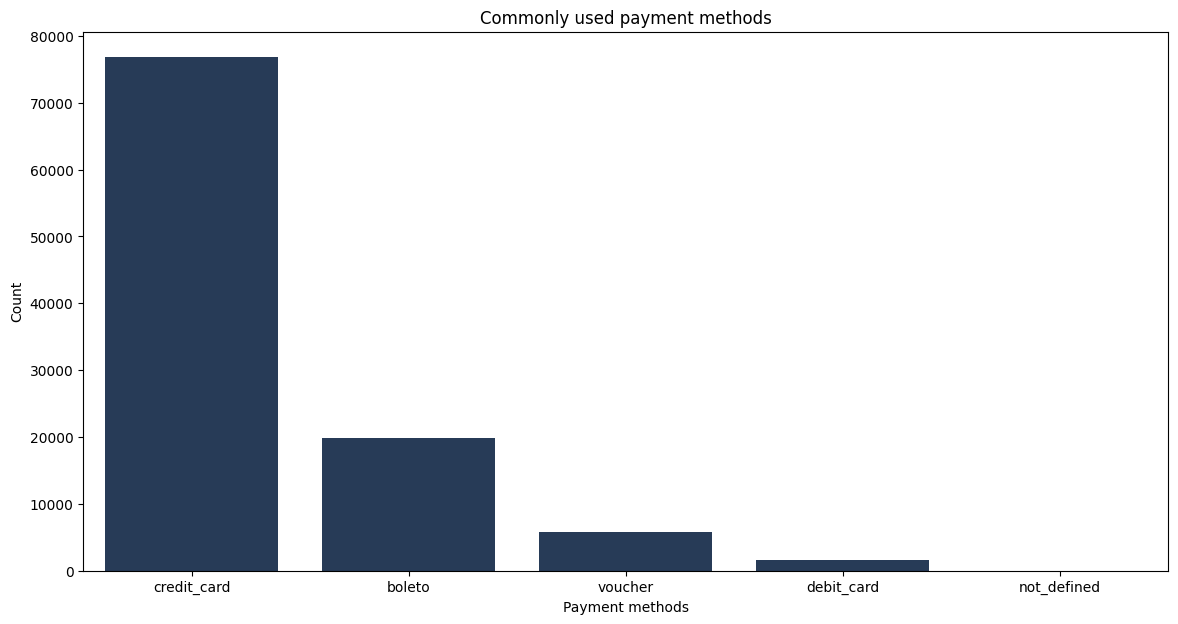

In [70]:
mlp.figure(figsize=(14,7))
mlp.title('Commonly used payment methods')
mlp.xlabel('Payment methods')
mlp.ylabel('Count')
sb.barplot(data=payment_methods,x='payment_type',y='order_id')

### Which payment method generates the highest revenue?

<Axes: title={'center': 'Revenue by payment methods'}, xlabel='payment_type', ylabel='payment_value (in CR)'>

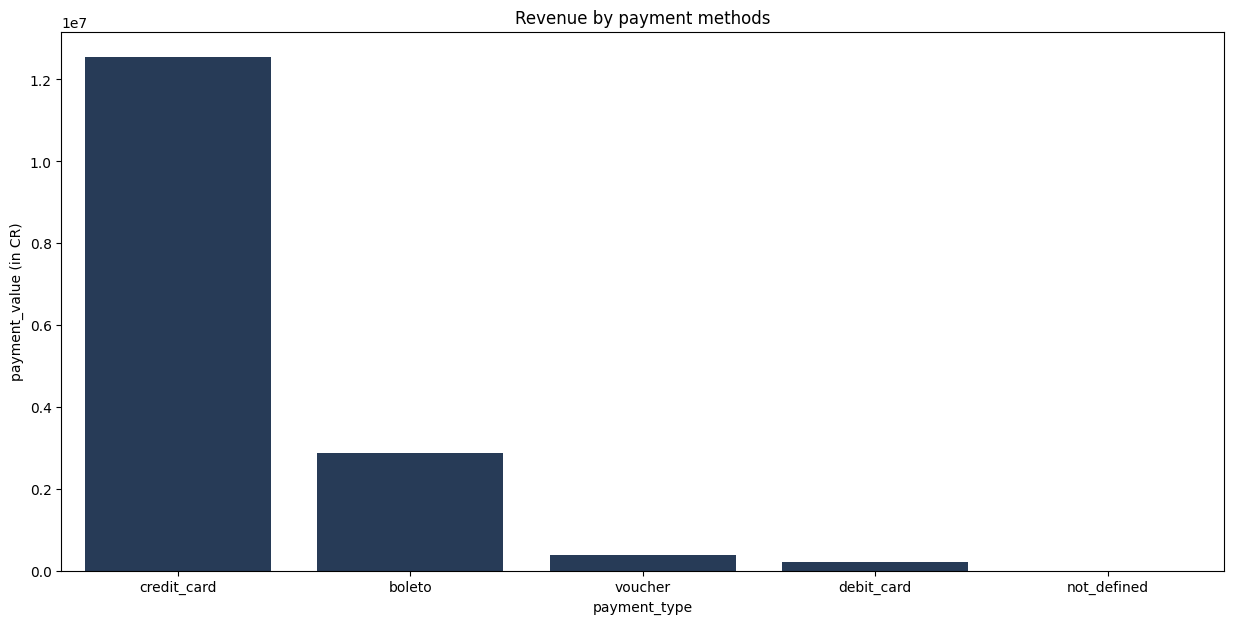

In [71]:
payment_methods = pd.read_csv(order_payments_data)[['payment_type','payment_value']]
payment_methods = payment_methods.groupby('payment_type')['payment_value'].sum()
payment_methods = pd.DataFrame(payment_methods)
payment_methods = payment_methods.sort_values(by='payment_value', ascending=False)
mlp.figure(figsize=(15,7))
mlp.title('Revenue by payment methods')
mlp.xlabel('payment_type')
mlp.ylabel('payment_value (in CR)')
sb.barplot(data=payment_methods,x='payment_type',y='payment_value',estimator=sum)

### What is the average payment value by payment type?

<Axes: title={'center': 'Average payment value by various payment methods'}, xlabel='payment_type', ylabel='payment_value'>

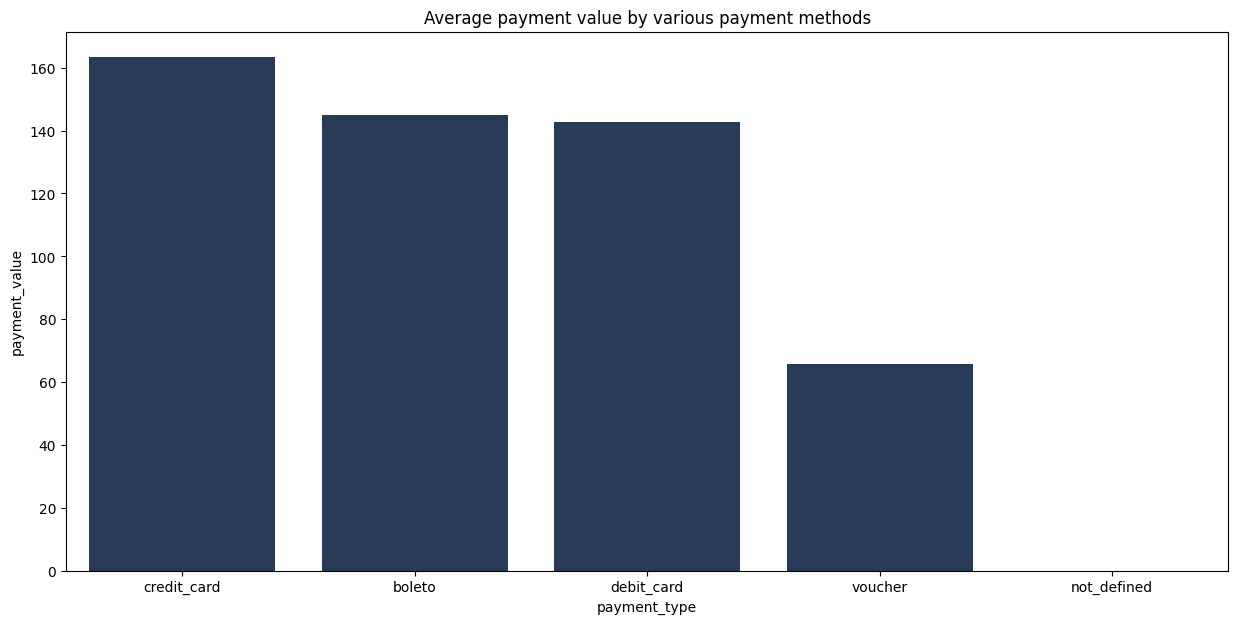

In [72]:
payment_methods = pd.read_csv(order_payments_data)[['payment_type','payment_value']]
payment_methods = payment_methods.groupby('payment_type')['payment_value'].mean()
payment_methods = pd.DataFrame(payment_methods)
payment_methods = payment_methods.sort_values(by='payment_value', ascending=False)
mlp.figure(figsize=(15,7))
mlp.title('Average payment value by various payment methods')
mlp.xlabel('payment_type')
mlp.ylabel('payment_value')
sb.barplot(data=payment_methods,x='payment_type',y='payment_value')

### Do high-value orders usually use more installments?

<Axes: title={'center': 'Payment value v/s Installments'}, xlabel='Installments', ylabel='Payment value'>

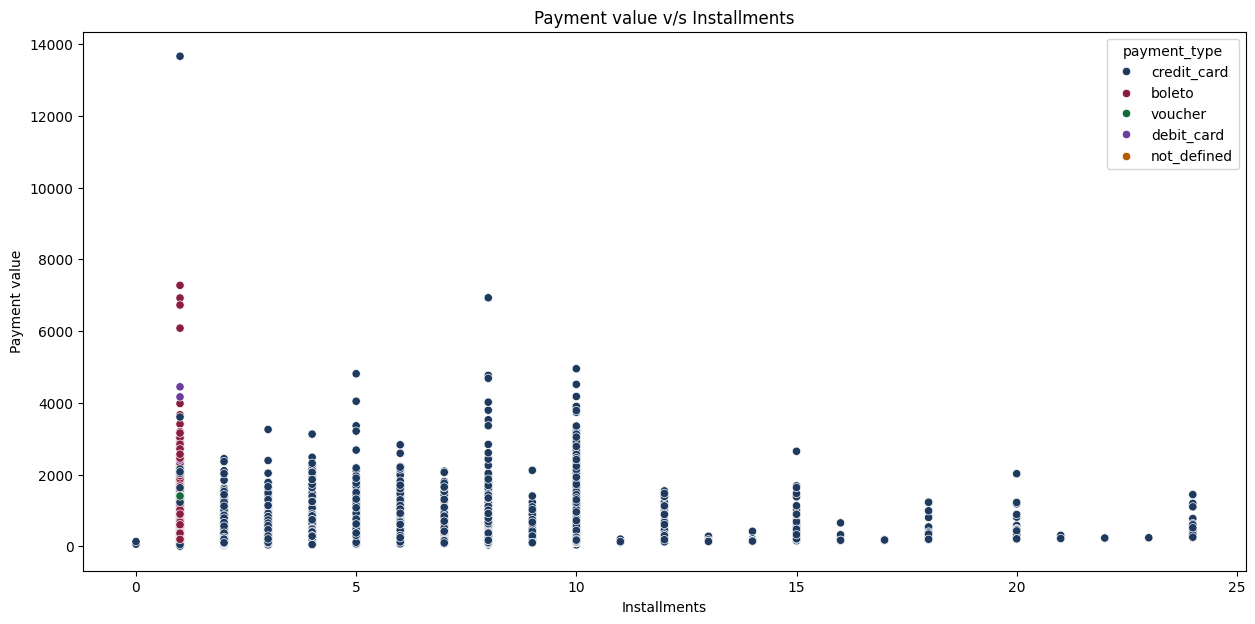

In [73]:
installments = pd.read_csv(order_payments_data)[['payment_installments','payment_value','payment_type']]
mlp.figure(figsize=(15,7))
mlp.title('Payment value v/s Installments')
mlp.xlabel('Installments')
mlp.ylabel('Payment value')
colors = ["#1F3A5F","#8B1E3F","#146B3A","#6A3D9A","#B35C00","#006D77","#5C4033" ]
sb.set_palette(colors)
sb.scatterplot(data=installments,x='payment_installments',y='payment_value',hue='payment_type')

### What is the distribution of 1-star to 5-star reviews?

In [74]:
reviews_data = pd.read_csv(order_reviews_data)[['review_score','review_id']]

In [75]:
reviews_data.shape

(99224, 2)

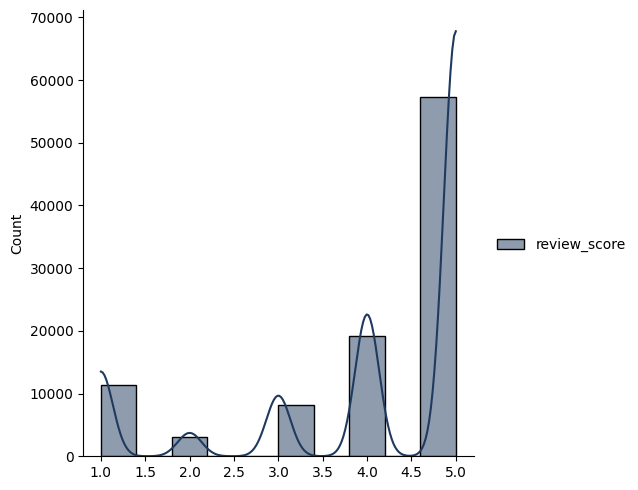

In [76]:
sb.displot(data=reviews_data,kde=True,color='blue',bins=10)

### Which states give the highest and lowest average review scores?

In [77]:
reviews = pd.read_csv(order_reviews_data)[['order_id','review_score']]
order_id_and_cust_id = pd.read_csv(orders_data)[['order_id','customer_id']]
cust_id_and_city = pd.read_csv(customer_dataset)[['customer_id','customer_state']]
order_id_and_cust_id = order_id_and_cust_id.set_index('order_id')['customer_id'].to_dict()
cust_id_and_city = cust_id_and_city.set_index('customer_id')['customer_state'].to_dict()

In [78]:
reviews['customer_id'] = reviews['order_id'].map(order_id_and_cust_id)

In [79]:
reviews['customer_state'] = reviews['customer_id'].map(cust_id_and_city)

In [80]:
reviews = reviews.groupby('customer_state')['review_score'].mean().to_frame()
reviews = reviews.sort_values(by='review_score',ascending=True)

In [81]:
reviews

,review_score
customer_state,
RR,3.608696
AL,3.751208
MA,3.764075
SE,3.808023
PA,3.849174
CE,3.851016
BA,3.860888
RJ,3.874971
PI,3.920570


<Axes: title={'center': 'Average reviews per state'}, xlabel='State', ylabel='Review score'>

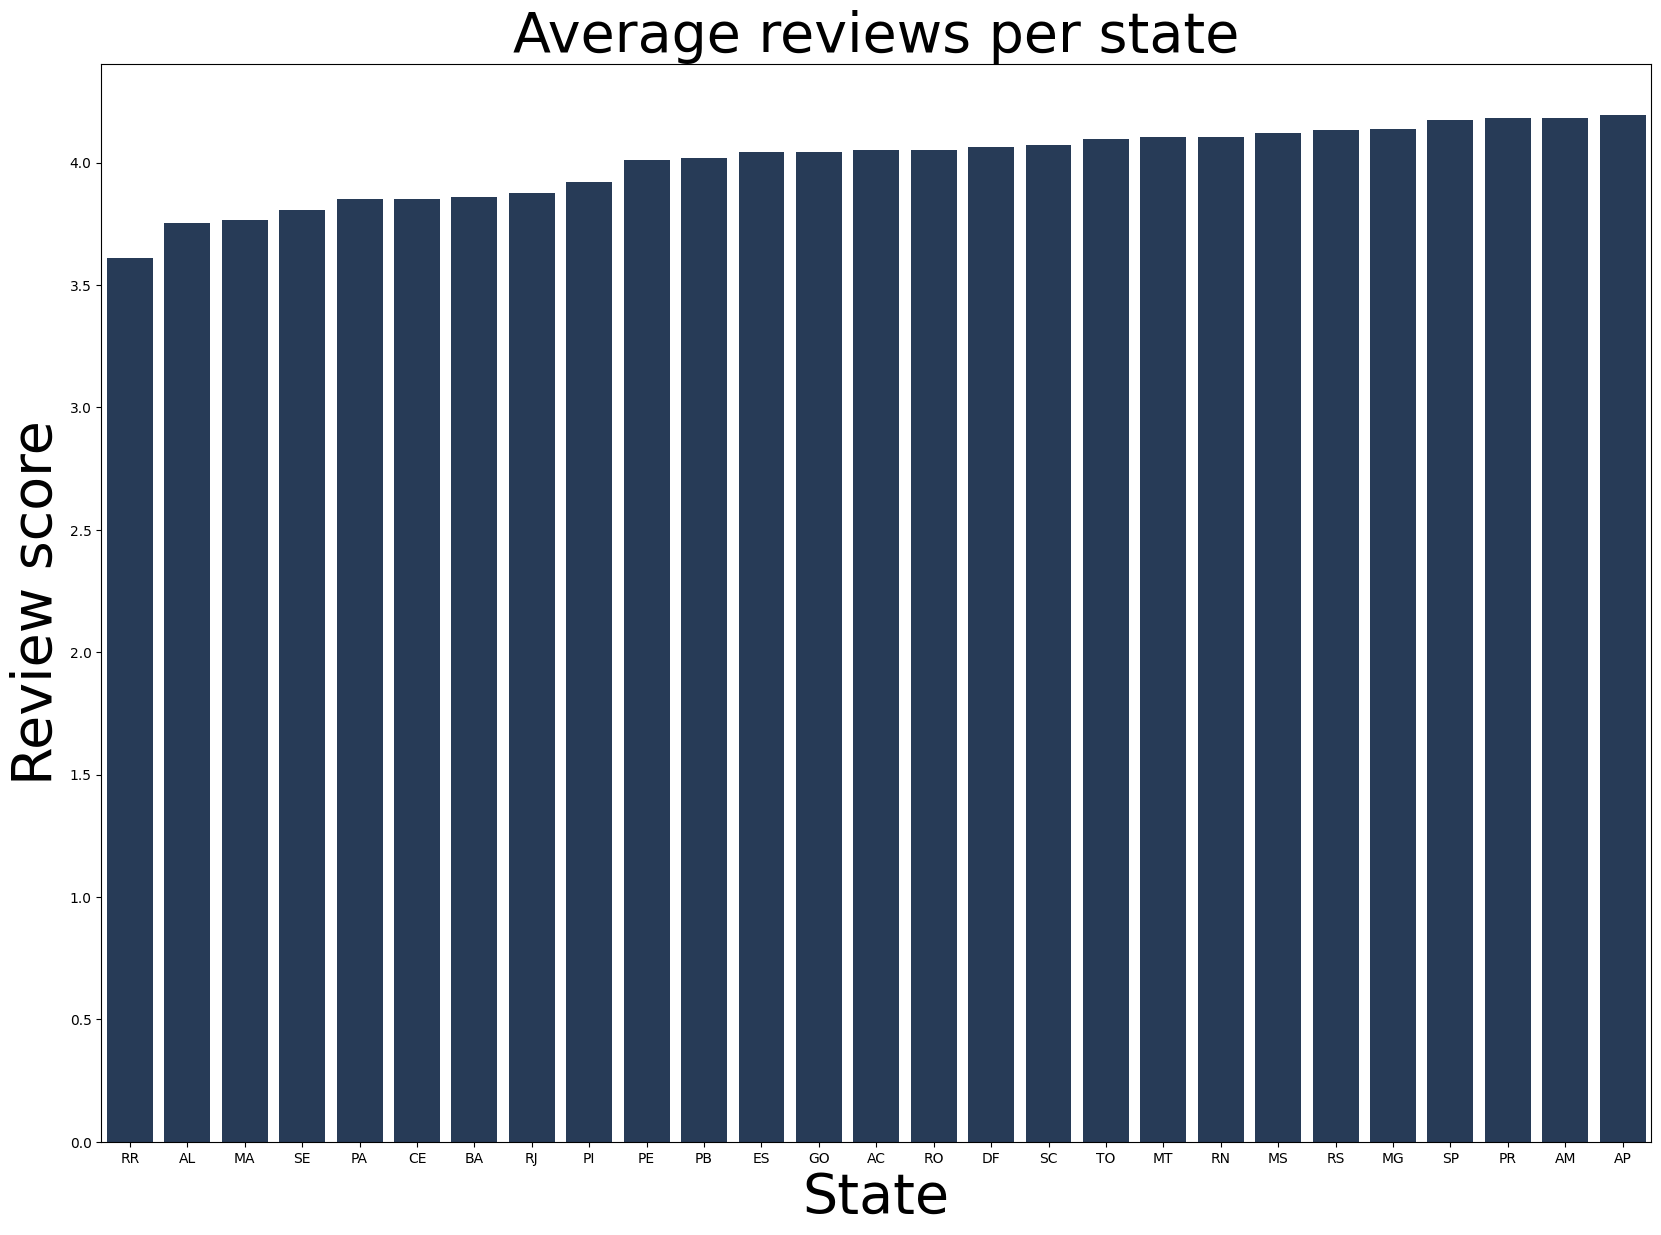

In [82]:
mlp.figure(figsize=(20,14))
mlp.title('Average reviews per state',fontsize=40)
mlp.xlabel('State',fontsize=40)
mlp.ylabel('Review score',fontsize=40)
sb.barplot(data=reviews,x='customer_state',y='review_score')

###  Do expensive products receive better or worse reviews?

In [83]:
reviews_data = pd.read_csv(order_reviews_data)[['order_id','review_score']]
amount_data = pd.read_csv(order_payments_data)[['order_id','payment_value']]
amount_data = amount_data.set_index('order_id')['payment_value'].to_dict()
reviews_data['amount'] = reviews_data['order_id'].map(amount_data)
reviews_data = reviews_data.sort_values(by='amount',ascending=True)

In [84]:
reviews_data

,order_id,review_score,amount
82219,4637ca194b6387e2d538dc89b124b0ee,3,0.00
91891,c8c528189310eaa44a745b8d9d26908b,1,0.00
9020,00b1cb0320190ca0daa2c88b35206009,1,0.00
94440,45ed6e85398a87c253db47c2d9f48216,1,0.00
41073,b23878b3e8eb4d25a158f57d96331b18,5,0.00
...,...,...,...
34097,f5136e38d1a14a4dbd87dff67da82701,5,6726.66
49217,0812eb902a67711a1cb742b3cdaa65ae,5,6929.31
18741,736e1922ae60d0d6a89247b851902527,1,7274.88
29746,03caa2c082116e1d31e67e9ae3700499,1,13664.08


Text(0, 0.5, 'Review score')

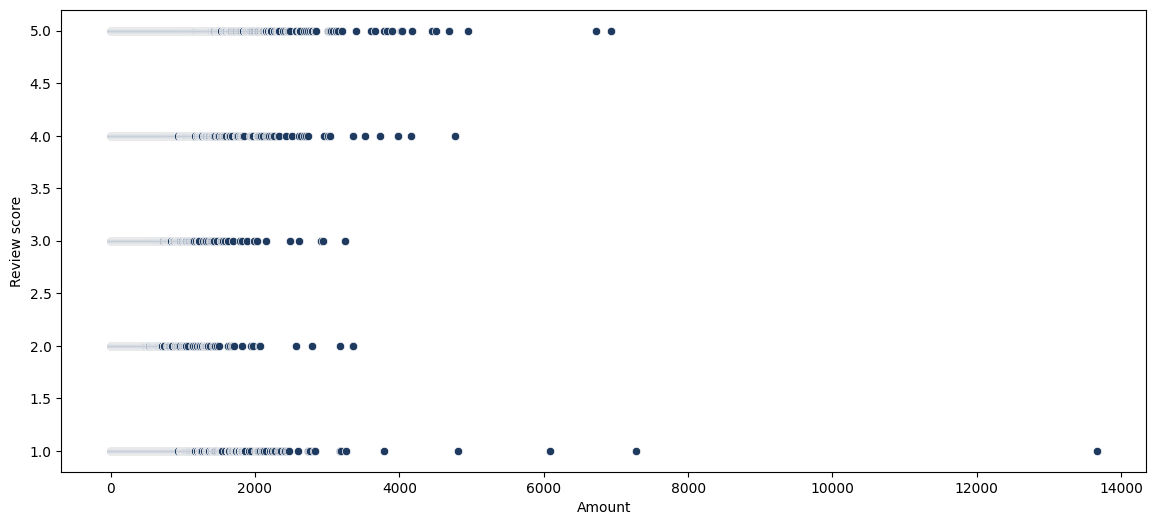

In [85]:
mlp.figure(figsize=(14,6))
sb.scatterplot(data=reviews_data,x='amount',y='review_score')
mlp.xlabel('Amount')
mlp.ylabel('Review score')

### Logistic developments


In [86]:
on_time = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\on_time_deliveries.csv"
late = r"D:\DATA ANALYSIS PROJECT\BRAZILIAN OLIST\CLEANED DATA\late_deliveries.csv"

on_time_deliveries = pd.read_csv(on_time)
late_deliveries = pd.read_csv(late)

In [87]:
on_time_deliveries['fast_delivery_rate'] = on_time_deliveries['fast_delivery_rate'].fillna(0)

In [88]:
on_time_deliveries

,seller_state,fast_deliveries,fast_delivery_rate
0,SP,73013,0.93
1,PR,8037,0.95
2,MG,8189,0.95
3,RJ,4361,0.93
4,DF,830,0.94
5,SC,3806,0.95
6,BA,596,0.96
7,MA,324,0.81
8,PE,430,0.97
9,ES,343,0.94


### On time deliveries

<Axes: title={'center': 'Fast deliveries'}, xlabel='State', ylabel='Fast delivery rate'>

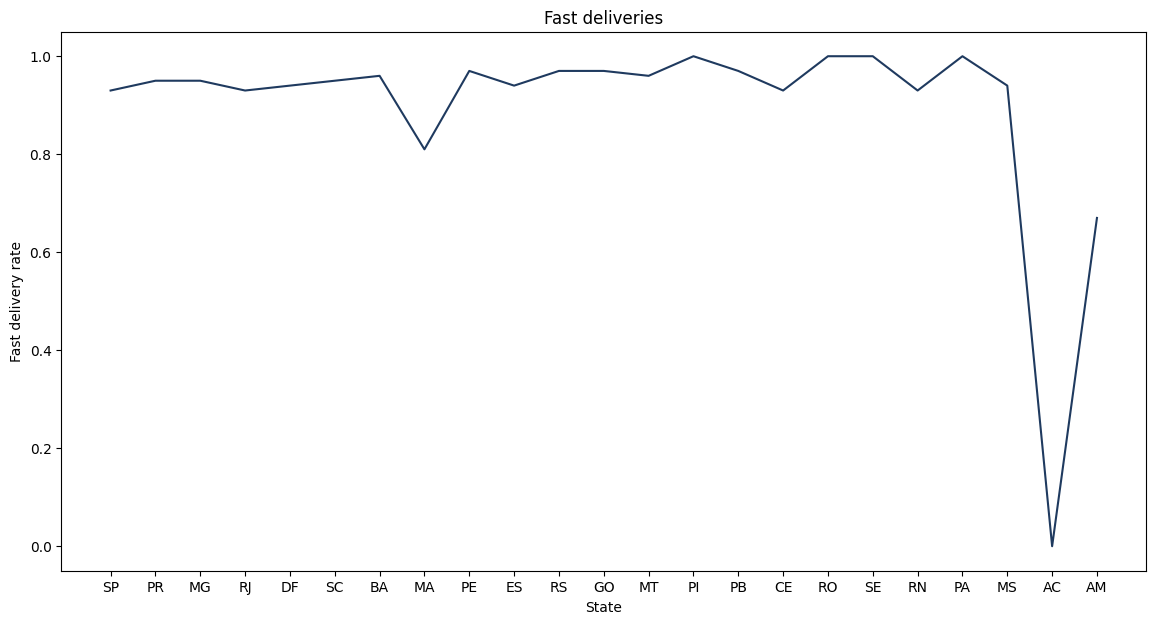

In [89]:
mlp.figure(figsize=(14,7))
mlp.xlabel('State')
mlp.ylabel('Fast delivery rate')
mlp.title('Fast deliveries')
sb.lineplot(data=on_time_deliveries,x='seller_state',y='fast_delivery_rate')

### Late deliveries

In [90]:
late_deliveries

,seller_state,late_deliveries,late_delivery_rate
0,SP,5585,0.07
1,PR,450,0.05
2,MG,412,0.05
3,RJ,324,0.07
4,DF,53,0.06
5,SC,194,0.05
6,BA,28,0.04
7,MA,78,0.19
8,PE,15,0.03
9,ES,21,0.06


<Axes: title={'center': 'Late deliveries'}, xlabel='State', ylabel='Late delivery rate'>

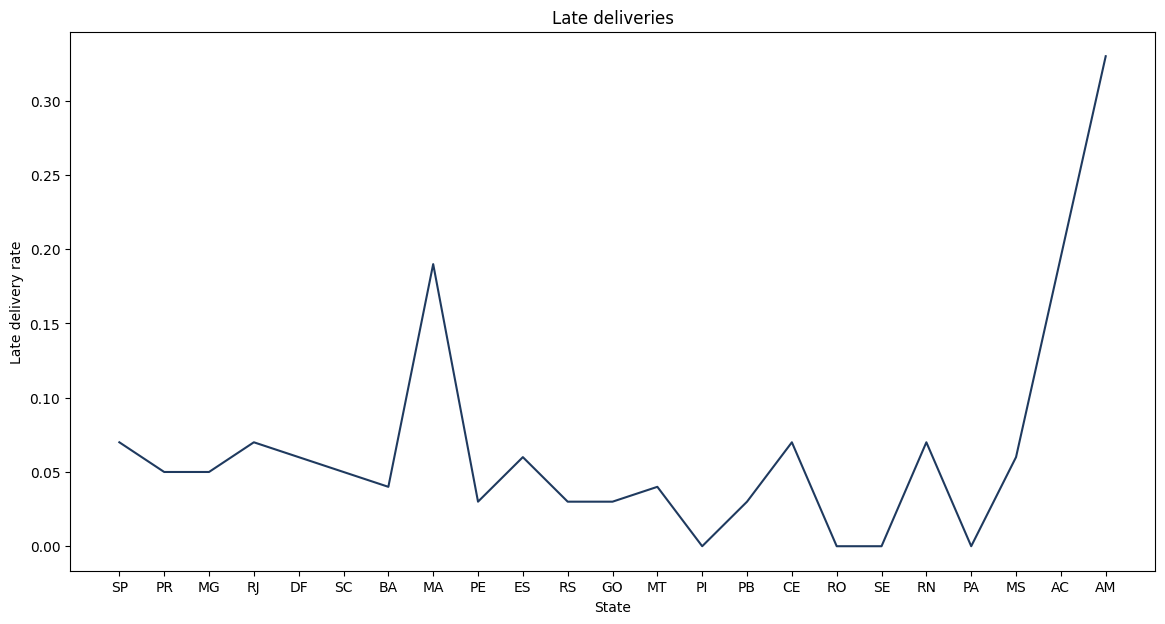

In [91]:
mlp.figure(figsize=(14,7))
mlp.xlabel('State')
mlp.ylabel('Late delivery rate')
mlp.title('Late deliveries')
sb.lineplot(data=late_deliveries,x='seller_state',y='late_delivery_rate')